# PCA — THS 2017 Trips-File Survey vs Cellular Matrix (robustness re-run)

Re-runs the PCA test suite of `THS_2018_MTX_PCA_vs_cellular.ipynb` on the **2017 trips-file survey source** (`Input/trips_ths_2017.xlsx`, via the saved day matrices of `THS_2017_trips_matrices.ipynb`) — the pipeline's **primary fusion source** — instead of the 2018 activities source. If the same structural conclusions hold, they are a property of survey-vs-cellular comparison generally, not an artifact of the 2018 activities processing.

The test design is identical (see the 2018 notebook for full rationale): origins are observations, row-normalized destination-share profiles are features, and every survey-vs-cellular statistic is judged against the survey's **day 1 vs day 2** internal-consistency ceiling and an explicit chance level.

| # | Test | Statistic |
|---|------|-----------|
| T1 | Dimensionality | scree, n₈₀, participation ratio |
| T2 | Subspace overlap | mean cos² of principal angles; permuted-geography null |
| T3 | Cross-projection | relative cross-explained variance RCEV(k) |
| T4 | Component matching | Tucker congruence, Hungarian-matched |
| T5 | Divergence map | joint-PCA displacement; sign-flip test |
| T6 | Divergence anatomy | diagonal share of ‖survey−cellular‖²; diagonal-ablation rerun |

**Inputs:** `Output/ths2017/matrix_day1_ALL.csv` / `matrix_day2_ALL.csv` (weighted day matrices in the trips file's `actTaz` zonation), converted here to the study zone systems with the exact allocation chain of `THS_2017_trips_matrices.ipynb`, and the cellular AM-peak matrix rebuilt from `Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import subspace_angles
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(42)

# palette (repo convention: blue = survey day 1, orange = survey day 2; aqua = cellular)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
CMAP_SEQ = LinearSegmentedColormap.from_list(
    'seq_blue', ['#fcfcfb', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])
CMAP_DIV = LinearSegmentedColormap.from_list(
    'div_blue_red', ['#0d366b', '#2a78d6', '#86b6ef', '#f0efec', '#f2a29e', '#e34948', '#7f1e1e'])

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

## 1. Data — conversion to the study zone systems

The saved day matrices live in the trips file's own `actTaz` zonation, so they are converted with the pipeline's chain (`THS_2017_trips_matrices.ipynb`): `actTaz` → `TAZ_1250` → study TAZ, the last one-to-many link allocated proportionally by cellular outflow/inflow shares (`M_taz = Sₒᵀ · M₁₂₅₀ · S_d`). Three validations anchor the conversion:

1. the rebuilt cellular study-TAZ probability matrix must match the saved `Output/prob_matrix_cellular.csv`;
2. the day-averaged converted matrix must match the saved `Output/ths2017/study_taz/matrix_avg_ALL_taz.csv`;
3. its `SZ_NEW` aggregation must match the saved `matrix_avg_ALL_sznew.csv`.

One convention note: the superzone key mapping follows the 2017 notebook (`drop_duplicates('TAZ_NUMBER')`, first occurrence). The 2018 comparison notebooks built their TAZ→SZ dict with last-occurrence precedence, so the superzone cellular matrix here differs from `Output/prob_sz_cellular.csv` in a handful of cells (max ≈ 0.07); each PCA notebook is internally consistent with its own pipeline's convention.

In [2]:
# mapping chain and allocation matrices (exact replica of THS_2017_trips_matrices.ipynb)
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636')
map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']

keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
kn = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER'])
kn['TAZ_NUMBER'] = kn['TAZ_NUMBER'].astype(int)
kd = kn.drop_duplicates('TAZ_NUMBER')

cellular = pd.read_csv('Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv')[['fromZone', 'ToZone', 'h6', 'h7', 'h8']]
c = cellular.merge(kd.rename(columns={'TAZ_1270': 'fromZone', 'TAZ_NUMBER': 'fromTaz'}), on='fromZone')
c = c.merge(kd.rename(columns={'TAZ_1270': 'ToZone', 'TAZ_NUMBER': 'ToTaz'}), on='ToZone')
cell_taz = c.groupby(['fromTaz', 'ToTaz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)
TAZ = cell_taz.index
out_vol, in_vol = cell_taz.sum(axis=1), cell_taz.sum(axis=0)

cell_taz_prob = cell_taz.div(cell_taz.sum(axis=1), axis=0).fillna(0)
saved_cell_prob = pd.read_csv('Output/prob_matrix_cellular.csv', index_col=0)
saved_cell_prob.columns = saved_cell_prob.columns.astype(int)
assert np.abs(cell_taz_prob.values - saved_cell_prob.reindex(index=TAZ, columns=TAZ).values).max() < 1e-6
print("validation 1: rebuilt cellular matrix matches Output/prob_matrix_cellular.csv")

north_1250 = sorted(kd[kd['TAZ_NUMBER'].isin(TAZ)]['TAZ_1270'].unique())
z_idx = {z: i for i, z in enumerate(north_1250)}
children = kd[kd['TAZ_NUMBER'].isin(TAZ)].groupby('TAZ_1270')['TAZ_NUMBER'].apply(list)

def alloc_matrix(vol):
    S = np.zeros((len(north_1250), len(TAZ)))
    taz_pos = {t: j for j, t in enumerate(TAZ)}
    for z, kids in children.items():
        v = np.array([vol[t] for t in kids], float)
        shares = v / v.sum() if v.sum() > 0 else np.full(len(kids), 1 / len(kids))
        for t, s in zip(kids, shares):
            S[z_idx[z], taz_pos[t]] = s
    return S

S_o, S_d = alloc_matrix(out_vol), alloc_matrix(in_vol)
assert np.allclose(S_o.sum(axis=1), 1) and np.allclose(S_d.sum(axis=1), 1)

validation 1: rebuilt cellular matrix matches Output/prob_matrix_cellular.csv


In [3]:
def day_to_taz(path):
    m = pd.read_csv(path, index_col=0)
    m.columns = m.columns.astype(float).astype(int)
    m.index = m.index.astype(float).astype(int)
    total = m.values.sum()
    long = m.stack()
    long = long[long > 0].reset_index()
    long.columns = ['o', 'd', 'v']
    long['o1250'] = long['o'].map(map_2636_1250)
    long['d1250'] = long['d'].map(map_2636_1250)
    ok = long['o1250'].isin(z_idx) & long['d1250'].isin(z_idx)
    kept = long.loc[ok, 'v'].sum() / total
    m1250 = (long[ok].groupby(['o1250', 'd1250'])['v'].sum().unstack()
             .reindex(index=north_1250, columns=north_1250, fill_value=0).fillna(0))
    m_taz = pd.DataFrame(S_o.T @ m1250.values @ S_d, index=TAZ, columns=TAZ)
    assert abs(m_taz.values.sum() - m1250.values.sum()) < 1e-6
    return m_taz, kept

d1_taz, kept1 = day_to_taz('Output/ths2017/matrix_day1_ALL.csv')
d2_taz, kept2 = day_to_taz('Output/ths2017/matrix_day2_ALL.csv')
print(f"weighted trips with both ends inside the study area: day 1 {kept1:.1%}, day 2 {kept2:.1%}")

saved_avg = pd.read_csv('Output/ths2017/study_taz/matrix_avg_ALL_taz.csv', index_col=0)
saved_avg.columns = saved_avg.columns.astype(int)
rel = np.abs(((d1_taz + d2_taz) / 2).values - saved_avg.values).max() / saved_avg.values.max()
assert rel < 1e-4
print(f"validation 2: day-average matches saved matrix_avg_ALL_taz (max rel diff {rel:.1e})")

taz_to_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW']

def agg_sz(m):
    m = m.copy()
    m.index.name, m.columns.name = 'o', 'd'
    long = m.stack().reset_index()
    long.columns = ['o', 'd', 'v']
    long['O'] = long['o'].map(taz_to_sz)
    long['D'] = long['d'].map(taz_to_sz)
    return long.dropna(subset=['O', 'D']).groupby(['O', 'D'])['v'].sum().unstack().fillna(0)

sz_d1_cnt, sz_d2_cnt, sz_cell_cnt = agg_sz(d1_taz), agg_sz(d2_taz), agg_sz(cell_taz)
saved_sz = pd.read_csv('Output/ths2017/study_taz/matrix_avg_ALL_sznew.csv', index_col=0)
rel_sz = np.abs(((sz_d1_cnt + sz_d2_cnt) / 2).values - saved_sz.values).max() / saved_sz.values.max()
assert rel_sz < 1e-4
print(f"validation 3: SZ day-average matches saved matrix_avg_ALL_sznew (max rel diff {rel_sz:.1e})")
assert list(sz_d1_cnt.index) == list(sz_cell_cnt.index)

def rownorm(m):
    return m.div(m.sum(axis=1), axis=0).fillna(0)

sz_cell, sz_s1, sz_s2 = rownorm(sz_cell_cnt), rownorm(sz_d1_cnt), rownorm(sz_d2_cnt)

common = TAZ[(d1_taz.sum(axis=1) > 0).values & (d2_taz.sum(axis=1) > 0).values]
taz_s1 = rownorm(d1_taz.loc[common])
taz_s2 = rownorm(d2_taz.loc[common])
taz_cell = cell_taz_prob.loc[common]
assert np.allclose(taz_s1.sum(axis=1), 1) and np.allclose(taz_cell.sum(axis=1), 1)
print(f"superzone matrices: {sz_cell.shape};  TAZ matrices: {len(common)} origins x {len(TAZ)} destinations")

weighted trips with both ends inside the study area: day 1 94.6%, day 2 94.8%


validation 2: day-average matches saved matrix_avg_ALL_taz (max rel diff 2.4e-06)


validation 3: SZ day-average matches saved matrix_avg_ALL_sznew (max rel diff 1.3e-16)
superzone matrices: (36, 36);  TAZ matrices: 697 origins x 778 destinations


In [4]:
# PCA machinery, identical to the 2018 notebook
def pca(P):
    X = np.asarray(P, dtype=float)
    Xc = X - X.mean(axis=0)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    lam = s ** 2 / (X.shape[0] - 1)
    return {'V': Vt.T, 'lam': lam, 'evr': lam / lam.sum(), 'scores': U * s}

def n_comp(evr, thr):
    return int(np.searchsorted(np.cumsum(evr), thr) + 1)

def part_ratio(lam):
    return float(lam.sum() ** 2 / (lam ** 2).sum())

def mean_cos2(Va, Vb, k):
    return float(np.mean(np.cos(subspace_angles(Va[:, :k], Vb[:, :k])) ** 2))

def rcev(P_target, pc_target, pc_source, k):
    Xc = np.asarray(P_target, float) - np.asarray(P_target, float).mean(axis=0)
    cap = ((Xc @ pc_source['V'][:, :k]) ** 2).sum() / (Xc.shape[0] - 1)
    return float(cap / pc_target['lam'][:k].sum())

P_SZ = {'cellular': sz_cell, 'survey d1': sz_s1, 'survey d2': sz_s2}
P_TAZ = {'cellular': taz_cell, 'survey d1': taz_s1, 'survey d2': taz_s2}
PC_SZ = {name: pca(P) for name, P in P_SZ.items()}
PC_TAZ = {name: pca(P) for name, P in P_TAZ.items()}

## 2. T1 — Dimensionality

In [5]:
rows = []
for lvl, PC in [('SZ', PC_SZ), ('TAZ', PC_TAZ)]:
    for name, pc in PC.items():
        rows.append({'level': lvl, 'matrix': name, 'PC1 share': pc['evr'][0],
                     'n80': n_comp(pc['evr'], .8), 'n90': n_comp(pc['evr'], .9),
                     'participation ratio': part_ratio(pc['lam'])})
t1 = pd.DataFrame(rows).set_index(['level', 'matrix'])

kSZ = n_comp(PC_SZ['cellular']['evr'], .8)
kTAZ = n_comp(PC_TAZ['cellular']['evr'], .8)
print(f"headline subspace dimension (80% of cellular variance): k = {kSZ} at SZ, k = {kTAZ} at TAZ")
t1.round(3)

headline subspace dimension (80% of cellular variance): k = 12 at SZ, k = 52 at TAZ


PC1 share  n80  n90  participation ratio
level matrix                                             
SZ    cellular       0.138   12   16               13.246
      survey d1      0.056   22   26               28.509
      survey d2      0.056   22   26               28.354
TAZ   cellular       0.065   52   86               41.153
      survey d1      0.026  122  158              140.076
      survey d2      0.030  118  156              136.405

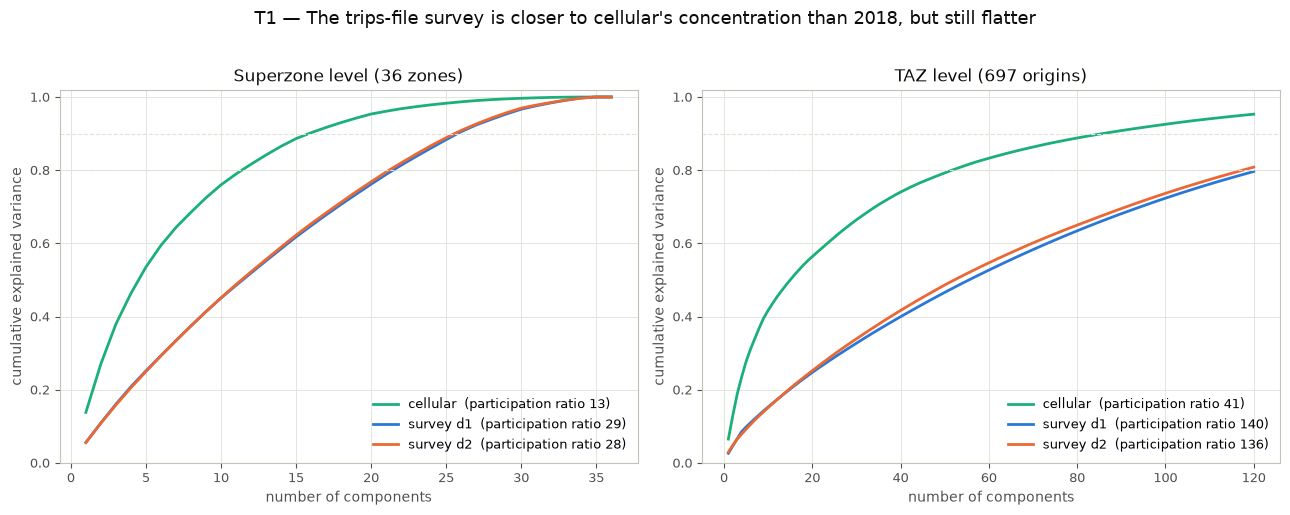

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
panels = [('Superzone level (36 zones)', PC_SZ, 36), (f'TAZ level ({len(common)} origins)', PC_TAZ, 120)]
for ax, (title, PC, pmax) in zip(axes, panels):
    for name, color in [('cellular', AQUA), ('survey d1', BLUE), ('survey d2', ORANGE)]:
        cum = np.cumsum(PC[name]['evr'])[:pmax]
        pr = part_ratio(PC[name]['lam'])
        ax.plot(range(1, len(cum) + 1), cum, color=color, linewidth=2,
                label=f"{name}  (participation ratio {pr:.0f})")
    for thr in (0.8, 0.9):
        ax.axhline(thr, color=GRID, linewidth=0.8, linestyle='--')
    ax.set_ylim(0, 1.02)
    style_ax(ax, title, 'number of components', 'cumulative explained variance')
    ax.legend(frameon=False, loc='lower right', fontsize=9)
fig.suptitle('T1 — The trips-file survey is closer to cellular\'s concentration than 2018, but still flatter',
             color=INK, fontsize=13, y=1.02)
plt.tight_layout()
save_show(fig, 'pca17_scree.png')

## 3. T2 — Subspace overlap, with the permuted-geography null

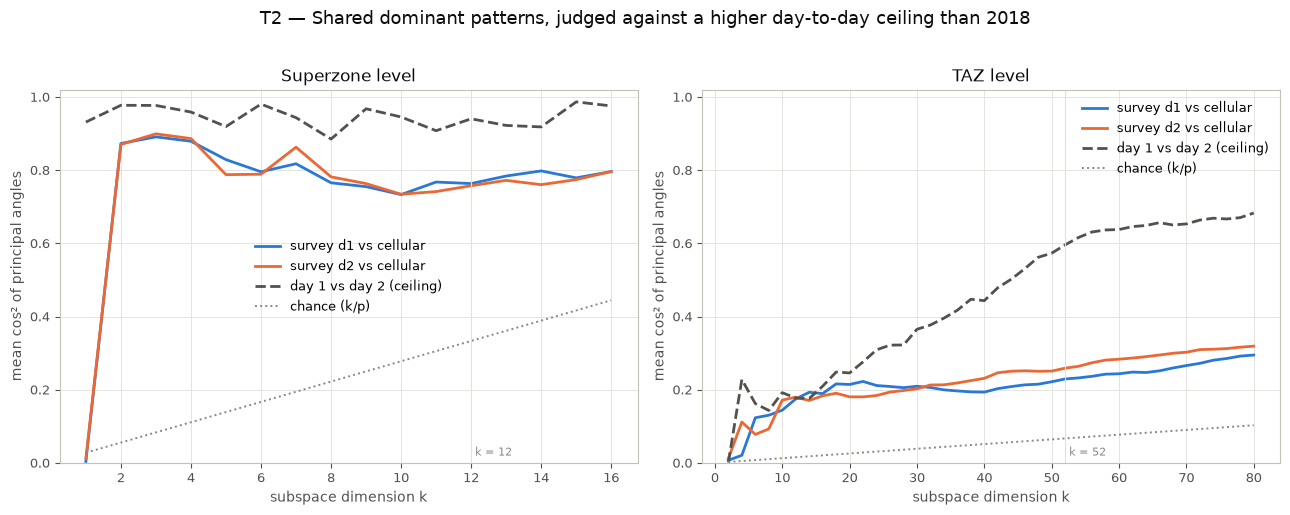

In [7]:
ks_sz, ks_taz = range(1, 17), range(2, 81, 2)
pairs = [('survey d1', 'cellular', BLUE), ('survey d2', 'cellular', ORANGE),
         ('survey d1', 'survey d2', INK2)]

def overlap_curves(PC, ks):
    return {(a, b): [mean_cos2(PC[a]['V'], PC[b]['V'], k) for k in ks] for a, b, _ in pairs}

ov_sz, ov_taz = overlap_curves(PC_SZ, ks_sz), overlap_curves(PC_TAZ, ks_taz)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
for ax, (title, ov, ks, p, khead) in zip(axes, [
        ('Superzone level', ov_sz, ks_sz, 36, kSZ), ('TAZ level', ov_taz, ks_taz, len(TAZ), kTAZ)]):
    for (a, b, color) in pairs:
        ls = '--' if a == 'survey d1' and b == 'survey d2' else '-'
        lbl = 'day 1 vs day 2 (ceiling)' if ls == '--' else f'{a} vs {b}'
        ax.plot(list(ks), ov[(a, b)], color=color, linewidth=2, linestyle=ls, label=lbl)
    ax.plot(list(ks), [k / p for k in ks], color=MUTED, linewidth=1.4, linestyle=':',
            label='chance (k/p)')
    ax.axvline(khead, color=GRID, linewidth=0.8)
    ax.text(khead, 0.02, f' k = {khead}', color=MUTED, fontsize=8)
    ax.set_ylim(0, 1.02)
    style_ax(ax, title, 'subspace dimension k', 'mean cos² of principal angles')
    ax.legend(frameon=False, loc='center' if p == 36 else 'upper right', fontsize=9)
fig.suptitle('T2 — Shared dominant patterns, judged against a higher day-to-day ceiling than 2018',
             color=INK, fontsize=13, y=1.02)
plt.tight_layout()
save_show(fig, 'pca17_subspace_overlap.png')

SZ: observed 0.763, ceiling 0.940, null mean 0.341 (max 0.530 in 2000 perms), p = 0.0005


TAZ: observed 0.229, ceiling 0.596, null mean 0.067 (max 0.090 in 500 perms), p = 0.0020


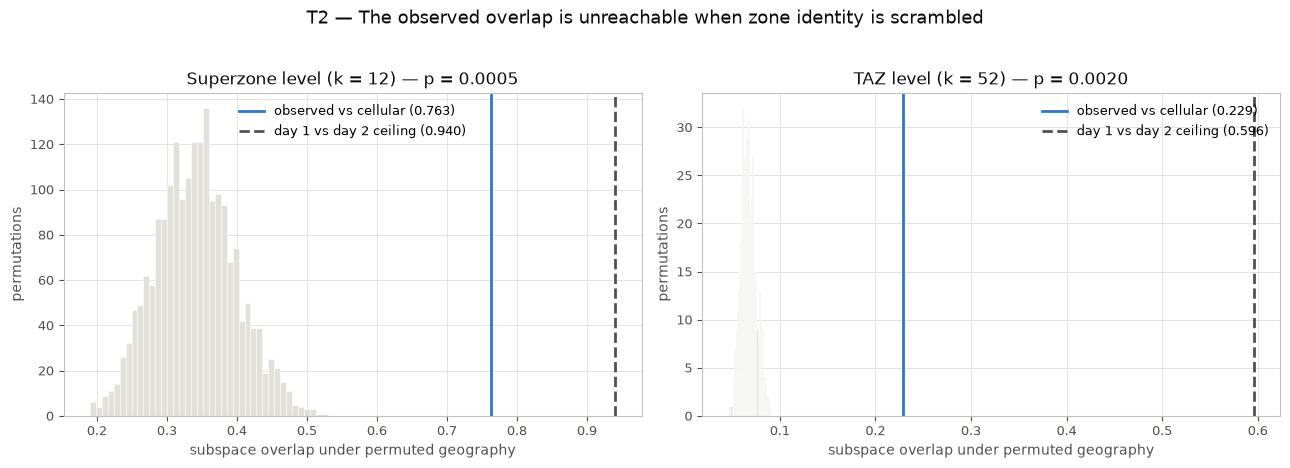

In [8]:
def perm_null(Vs, Vc, k, n_perm, seed=0):
    r = np.random.default_rng(seed)
    p = Vs.shape[0]
    return np.array([mean_cos2(Vs[r.permutation(p)], Vc, k) for _ in range(n_perm)])

perm = {}
for lvl, PC, k, n_perm in [('SZ', PC_SZ, kSZ, 2000), ('TAZ', PC_TAZ, kTAZ, 500)]:
    null = perm_null(PC['survey d1']['V'], PC['cellular']['V'], k, n_perm)
    obs = mean_cos2(PC['survey d1']['V'], PC['cellular']['V'], k)
    ceil = mean_cos2(PC['survey d1']['V'], PC['survey d2']['V'], k)
    pval = (1 + (null >= obs).sum()) / (1 + len(null))
    perm[lvl] = dict(null=null, obs=obs, ceil=ceil, p=pval, k=k)
    print(f"{lvl}: observed {obs:.3f}, ceiling {ceil:.3f}, null mean {null.mean():.3f} "
          f"(max {null.max():.3f} in {n_perm} perms), p = {pval:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='white')
for ax, lvl, title in zip(axes, ['SZ', 'TAZ'], ['Superzone level', 'TAZ level']):
    d = perm[lvl]
    ax.hist(d['null'], bins=40, color=GRID, edgecolor='white', linewidth=0.4)
    ax.axvline(d['obs'], color=BLUE, linewidth=2,
               label=f"observed vs cellular ({d['obs']:.3f})")
    ax.axvline(d['ceil'], color=INK2, linewidth=2, linestyle='--',
               label=f"day 1 vs day 2 ceiling ({d['ceil']:.3f})")
    style_ax(ax, f"{title} (k = {d['k']}) — p = {d['p']:.4f}",
             'subspace overlap under permuted geography', 'permutations')
    ax.legend(frameon=False, fontsize=9)
fig.suptitle('T2 — The observed overlap is unreachable when zone identity is scrambled',
             color=INK, fontsize=13, y=1.03)
plt.tight_layout()
save_show(fig, 'pca17_perm_null.png')

## 4. T3 — Cross-projection (RCEV)

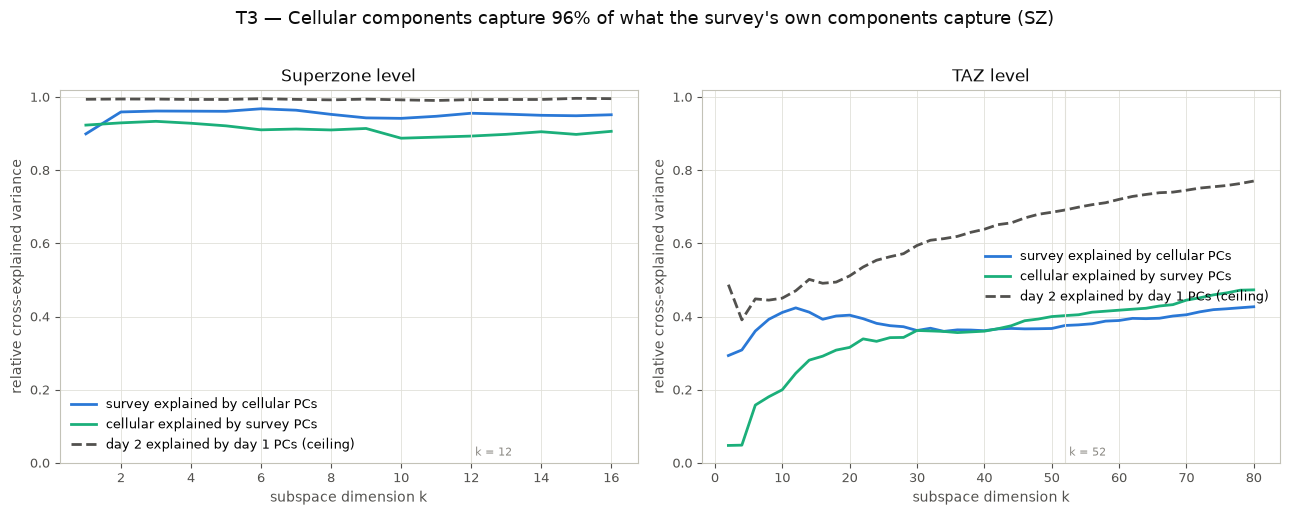

SZ (k = 12): survey|cellular 0.956, cellular|survey 0.893, ceiling 0.993
TAZ (k = 52): survey|cellular 0.376, cellular|survey 0.403, ceiling 0.691


In [9]:
cross = [('survey d1', 'cellular', BLUE, '-', 'survey explained by cellular PCs'),
         ('cellular', 'survey d1', AQUA, '-', 'cellular explained by survey PCs'),
         ('survey d2', 'survey d1', INK2, '--', 'day 2 explained by day 1 PCs (ceiling)')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
for ax, (title, P, PC, ks, khead) in zip(axes, [
        ('Superzone level', P_SZ, PC_SZ, ks_sz, kSZ), ('TAZ level', P_TAZ, PC_TAZ, ks_taz, kTAZ)]):
    for tgt, src, color, ls, lbl in cross:
        vals = [rcev(P[tgt], PC[tgt], PC[src], k) for k in ks]
        ax.plot(list(ks), vals, color=color, linewidth=2, linestyle=ls, label=lbl)
    ax.axvline(khead, color=GRID, linewidth=0.8)
    ax.text(khead, 0.02, f' k = {khead}', color=MUTED, fontsize=8)
    ax.set_ylim(0, 1.02)
    style_ax(ax, title, 'subspace dimension k', 'relative cross-explained variance')
    ax.legend(frameon=False, loc='lower left' if khead == kSZ else 'center right', fontsize=9)
fig.suptitle('T3 — Cellular components capture 96% of what the survey\'s own components capture (SZ)',
             color=INK, fontsize=13, y=1.02)
plt.tight_layout()
save_show(fig, 'pca17_cross_projection.png')

for lvl, P, PC, k in [('SZ', P_SZ, PC_SZ, kSZ), ('TAZ', P_TAZ, PC_TAZ, kTAZ)]:
    print(f"{lvl} (k = {k}): survey|cellular {rcev(P['survey d1'], PC['survey d1'], PC['cellular'], k):.3f}, "
          f"cellular|survey {rcev(P['cellular'], PC['cellular'], PC['survey d1'], k):.3f}, "
          f"ceiling {rcev(P['survey d2'], PC['survey d2'], PC['survey d1'], k):.3f}")

## 5. T4 — Component matching

survey PC1 <-> cellular PC2: |congruence| = 0.965
survey PC2 <-> cellular PC1: |congruence| = 0.896
survey PC4 <-> cellular PC4: |congruence| = 0.881
survey PC3 <-> cellular PC3: |congruence| = 0.869
survey PC5 <-> cellular PC5: |congruence| = 0.723
survey PC6 <-> cellular PC6: |congruence| = 0.530


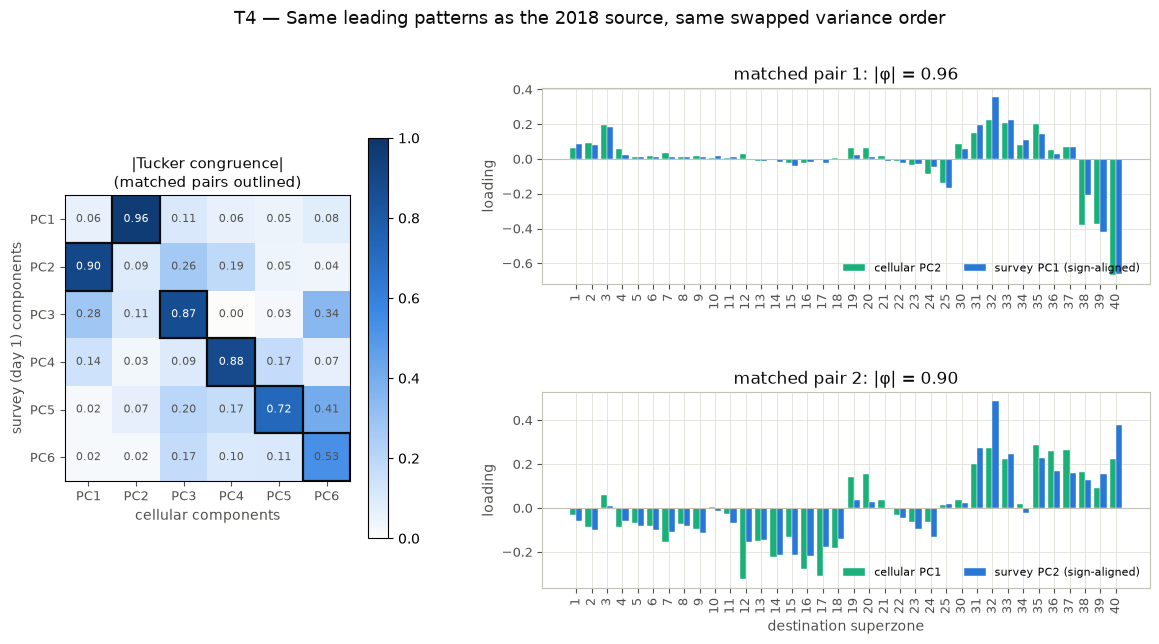

In [10]:
kc = 6
C = PC_SZ['survey d1']['V'][:, :kc].T @ PC_SZ['cellular']['V'][:, :kc]
ri, ci = linear_sum_assignment(-np.abs(C))
match = sorted(zip(ri, ci), key=lambda x: -abs(C[x[0], x[1]]))
for i, j in match:
    print(f"survey PC{i+1} <-> cellular PC{j+1}: |congruence| = {abs(C[i, j]):.3f}")

sz_ids = sz_cell.index.to_numpy()
fig = plt.figure(figsize=(14, 6.5), facecolor='white')
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.7], hspace=0.55, wspace=0.25)

ax = fig.add_subplot(gs[:, 0])
im = ax.imshow(np.abs(C), cmap=CMAP_SEQ, vmin=0, vmax=1)
for i in range(kc):
    for j in range(kc):
        v = abs(C[i, j])
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if v > 0.55 else INK2)
for i, j in zip(ri, ci):
    ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, edgecolor=INK, linewidth=1.6))
ax.set_xticks(range(kc), [f'PC{j+1}' for j in range(kc)])
ax.set_yticks(range(kc), [f'PC{i+1}' for i in range(kc)])
ax.set_xlabel('cellular components', color=INK2, fontsize=10)
ax.set_ylabel('survey (day 1) components', color=INK2, fontsize=10)
ax.set_title('|Tucker congruence|\n(matched pairs outlined)', color=INK, fontsize=11)
ax.tick_params(colors=INK2, labelsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)

x = np.arange(len(sz_ids))
for row, (i, j) in enumerate(match[:2]):
    ax = fig.add_subplot(gs[row, 1])
    sgn = np.sign(C[i, j])
    ax.bar(x - 0.2, PC_SZ['cellular']['V'][:, j], width=0.4, color=AQUA,
           edgecolor='white', linewidth=0.3, label=f'cellular PC{j+1}')
    ax.bar(x + 0.2, sgn * PC_SZ['survey d1']['V'][:, i], width=0.4, color=BLUE,
           edgecolor='white', linewidth=0.3, label=f'survey PC{i+1} (sign-aligned)')
    ax.set_xticks(x, sz_ids, fontsize=6.5, rotation=90)
    style_ax(ax, f'matched pair {row+1}: |φ| = {abs(C[i, j]):.2f}',
             'destination superzone' if row == 1 else None, 'loading')
    ax.axhline(0, color=AXIS, linewidth=0.8)
    ax.legend(frameon=False, fontsize=8, loc='lower right', ncols=2)
fig.suptitle('T4 — Same leading patterns as the 2018 source, same swapped variance order',
             color=INK, fontsize=13, y=1.0)
save_show(fig, 'pca17_component_match.png')

In [11]:
# interpretation: correlate component scores with the origin's self-containment
for name in ['cellular', 'survey d1']:
    P, pc = P_SZ[name], PC_SZ[name]
    for j in range(3):
        r = np.corrcoef(pc['scores'][:, j], np.diag(P.values))[0, 1]
        print(f"{name} PC{j+1}: corr(score, self-containment) = {r:+.3f}, "
              f"variance share {pc['evr'][j]:.3f}")

cellular PC1: corr(score, self-containment) = +0.771, variance share 0.138
cellular PC2: corr(score, self-containment) = -0.029, variance share 0.133
cellular PC3: corr(score, self-containment) = -0.113, variance share 0.109
survey d1 PC1: corr(score, self-containment) = +0.048, variance share 0.056
survey d1 PC2: corr(score, self-containment) = +0.799, variance share 0.053
survey d1 PC3: corr(score, self-containment) = -0.111, variance share 0.051


## 6. T5 — Joint PCA: where do the sources diverge?

mean profile distance: survey vs cellular 0.371, day 1 vs day 2 0.041 -> displacement ratio 9.1x
mean self-containment: survey (2017 trips file) 0.681, cellular 0.338
common-direction test: |mean difference| = 0.0608, sign-flip P(null >= obs) = 0.9306
  -> no common bias direction; the divergence is zone-specific
corr(per-zone displacement, |self-containment difference|) = 0.992


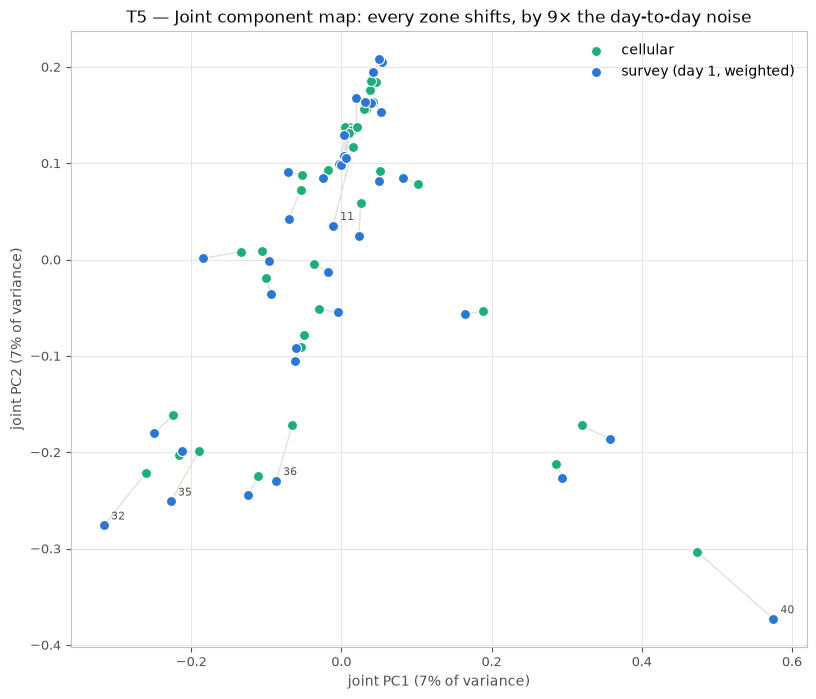

In [12]:
S = np.vstack([sz_cell.values, sz_s1.values])
pcJ = pca(S)
n = len(sz_cell)
sc_c, sc_s = pcJ['scores'][:n], pcJ['scores'][n:]

disp = np.linalg.norm(sz_s1.values - sz_cell.values, axis=1)
disp_days = np.linalg.norm(sz_s1.values - sz_s2.values, axis=1)
Dm = sz_s1.values - sz_cell.values
obs_shift = np.linalg.norm(Dm.mean(axis=0))
flips = rng.choice([-1., 1.], size=(10000, n))
null_shift = np.linalg.norm((flips[:, :, None] * Dm[None]).mean(axis=1), axis=1)
p_hi = (1 + (null_shift >= obs_shift).sum()) / 10001
self_diff = np.diag(sz_s1.values) - np.diag(sz_cell.values)
r_selfdiff = np.corrcoef(disp, np.abs(self_diff))[0, 1]

print(f"mean profile distance: survey vs cellular {disp.mean():.3f}, day 1 vs day 2 {disp_days.mean():.3f} "
      f"-> displacement ratio {disp.mean() / disp_days.mean():.1f}x")
print(f"mean self-containment: survey (2017 trips file) {np.diag(sz_s1.values).mean():.3f}, cellular {np.diag(sz_cell.values).mean():.3f}")
print(f"common-direction test: |mean difference| = {obs_shift:.4f}, sign-flip P(null >= obs) = {p_hi:.4f}")
print(f"  -> no common bias direction; the divergence is zone-specific")
print(f"corr(per-zone displacement, |self-containment difference|) = {r_selfdiff:.3f}")

d2m = np.linalg.norm(sc_s[:, :2] - sc_c[:, :2], axis=1)
top = np.argsort(-d2m)[:5]

fig, ax = plt.subplots(figsize=(9.5, 8), facecolor='white')
for i in range(n):
    ax.plot([sc_c[i, 0], sc_s[i, 0]], [sc_c[i, 1], sc_s[i, 1]],
            color=GRID, linewidth=1.0, zorder=1)
ax.scatter(sc_c[:, 0], sc_c[:, 1], s=52, color=AQUA, edgecolors='white',
           linewidths=0.8, zorder=2, label='cellular')
ax.scatter(sc_s[:, 0], sc_s[:, 1], s=52, color=BLUE, edgecolors='white',
           linewidths=0.8, zorder=2, label='survey (day 1, weighted)')
for i in top:
    ax.annotate(str(sz_ids[i]), (sc_s[i, 0], sc_s[i, 1]), textcoords='offset points',
                xytext=(5, 4), fontsize=8, color=INK2)
style_ax(ax,
         f'T5 — Joint component map: every zone shifts, by {disp.mean() / disp_days.mean():.0f}× the day-to-day noise',
         f"joint PC1 ({pcJ['evr'][0]:.0%} of variance)", f"joint PC2 ({pcJ['evr'][1]:.0%} of variance)")
ax.legend(frameon=False, fontsize=10)
save_show(fig, 'pca17_joint_map.png')

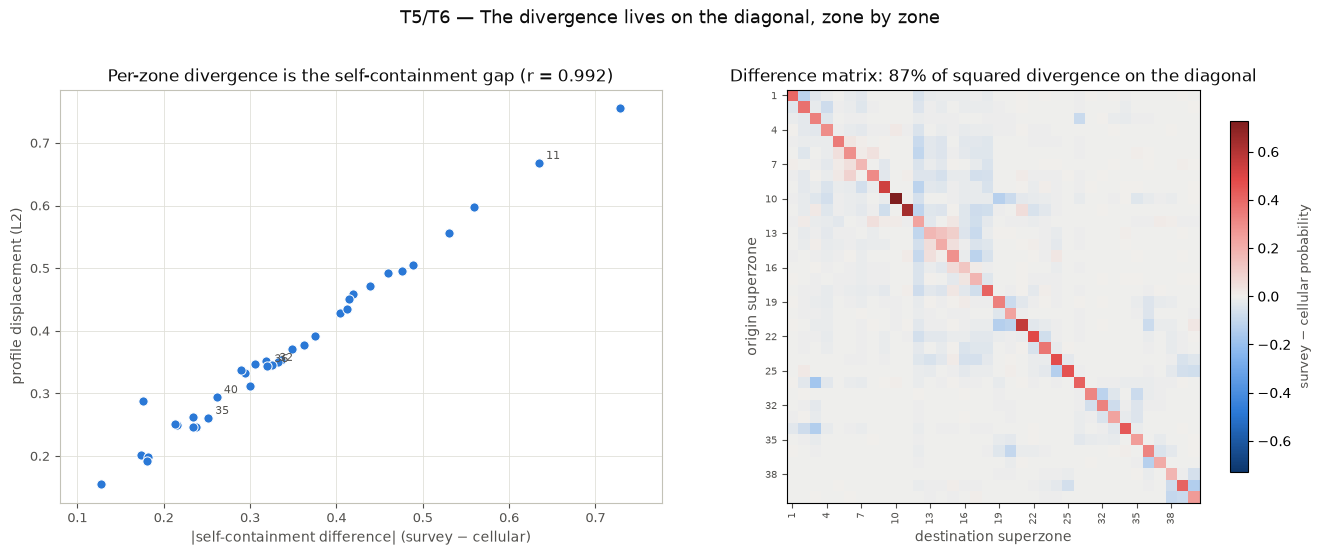

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), facecolor='white')

ax = axes[0]
ax.margins(x=0.08)
ax.scatter(np.abs(self_diff), disp, s=44, color=BLUE, edgecolors='white', linewidths=0.7)
for i in top:
    ax.annotate(str(sz_ids[i]), (abs(self_diff[i]), disp[i]), textcoords='offset points',
                xytext=(5, 3), fontsize=8, color=INK2)
style_ax(ax, f'Per-zone divergence is the self-containment gap (r = {r_selfdiff:.3f})',
         '|self-containment difference| (survey − cellular)', 'profile displacement (L2)')

ax = axes[1]
D = sz_s1.values - sz_cell.values
vmax = np.abs(D).max()
im = ax.imshow(D, cmap=CMAP_DIV, vmin=-vmax, vmax=vmax)
diag_share = (np.diag(D) ** 2).sum() / (D ** 2).sum()
ax.set_title(f'Difference matrix: {diag_share:.0%} of squared divergence on the diagonal',
             color=INK, fontsize=12)
step = 3
ax.set_xticks(range(0, n, step), sz_ids[::step], fontsize=7, rotation=90)
ax.set_yticks(range(0, n, step), sz_ids[::step], fontsize=7)
ax.set_xlabel('destination superzone', color=INK2, fontsize=10)
ax.set_ylabel('origin superzone', color=INK2, fontsize=10)
ax.tick_params(colors=INK2)
cb = fig.colorbar(im, ax=ax, shrink=0.85)
cb.set_label('survey − cellular probability', color=INK2, fontsize=9)
fig.suptitle('T5/T6 — The divergence lives on the diagonal, zone by zone', color=INK, fontsize=13, y=1.02)
plt.tight_layout()
save_show(fig, 'pca17_divergence_structure.png')

## 7. T6 — Diagonal ablation

SZ: diagonal share of squared divergence 0.872; diagonal removed (36 rows kept): overlap 0.715 (ceiling 0.887), RCEV 0.839 (ceiling 0.963)


TAZ: diagonal share of squared divergence 0.007; diagonal removed (697 rows kept): overlap 0.230 (ceiling 0.591), RCEV 0.374 (ceiling 0.691)


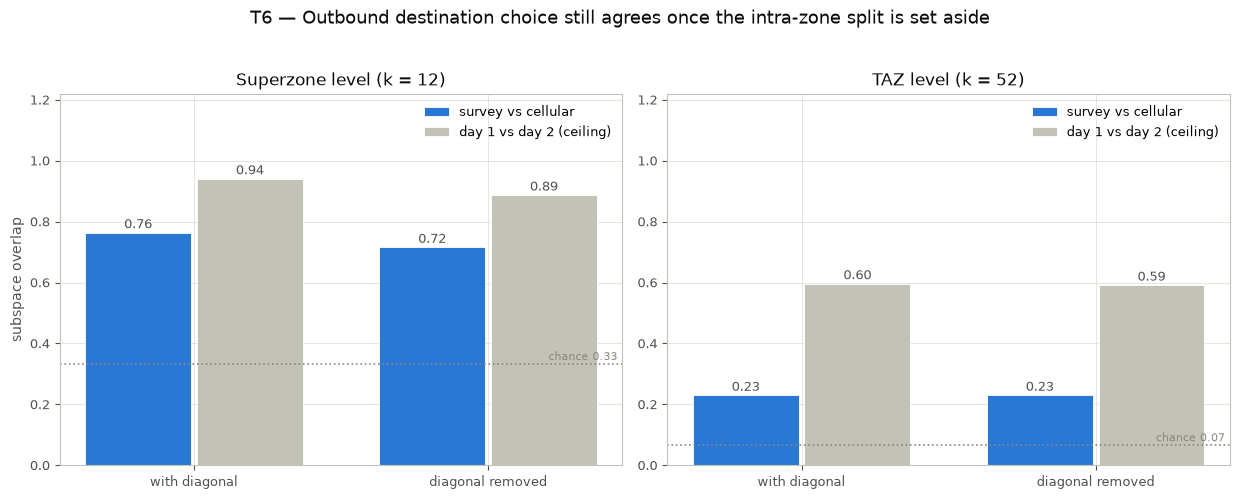

In [14]:
def strip_diag(P):
    A = np.asarray(P, float).copy()
    np.fill_diagonal(A, 0)
    rs = A.sum(axis=1, keepdims=True)
    ok = rs[:, 0] > 0
    A = np.divide(A, rs, out=np.zeros_like(A), where=rs > 0)
    return A, ok

ablation = {}
for lvl, P, k in [('SZ', P_SZ, kSZ), ('TAZ', P_TAZ, kTAZ)]:
    stripped = {name: strip_diag(v) for name, v in P.items()}
    ok = np.logical_and.reduce([s[1] for s in stripped.values()])
    Px = {name: s[0][ok] for name, s in stripped.items()}
    PCx = {name: pca(v) for name, v in Px.items()}
    ablation[lvl] = {
        'rows': int(ok.sum()),
        'overlap': mean_cos2(PCx['survey d1']['V'], PCx['cellular']['V'], k),
        'ceiling': mean_cos2(PCx['survey d1']['V'], PCx['survey d2']['V'], k),
        'rcev': rcev(Px['survey d1'], PCx['survey d1'], PCx['cellular'], k),
        'rcev_ceiling': rcev(Px['survey d2'], PCx['survey d2'], PCx['survey d1'], k),
    }
    D = P['survey d1'].values - P['cellular'].values
    diag_sh = (np.diag(D) ** 2).sum() / (D ** 2).sum()
    print(f"{lvl}: diagonal share of squared divergence {diag_sh:.3f}; "
          f"diagonal removed ({ablation[lvl]['rows']} rows kept): overlap {ablation[lvl]['overlap']:.3f} "
          f"(ceiling {ablation[lvl]['ceiling']:.3f}), RCEV {ablation[lvl]['rcev']:.3f} "
          f"(ceiling {ablation[lvl]['rcev_ceiling']:.3f})")

with_diag = {
    'SZ': (perm['SZ']['obs'], perm['SZ']['ceil']),
    'TAZ': (perm['TAZ']['obs'], perm['TAZ']['ceil']),
}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), facecolor='white')
for ax, lvl, p, k in zip(axes, ['SZ', 'TAZ'], [36, len(TAZ)], [kSZ, kTAZ]):
    groups = ['with diagonal', 'diagonal removed']
    surv = [with_diag[lvl][0], ablation[lvl]['overlap']]
    ceil = [with_diag[lvl][1], ablation[lvl]['ceiling']]
    x = np.arange(2)
    b1 = ax.bar(x - 0.19, surv, width=0.36, color=BLUE, edgecolor='white', linewidth=0.6,
                label='survey vs cellular')
    b2 = ax.bar(x + 0.19, ceil, width=0.36, color=AXIS, edgecolor='white', linewidth=0.6,
                label='day 1 vs day 2 (ceiling)')
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015, f'{b.get_height():.2f}',
                    ha='center', color=INK2, fontsize=9)
    ax.axhline(k / p, color=MUTED, linewidth=1.2, linestyle=':')
    ax.text(1.44, k / p + 0.012, f'chance {k / p:.2f}', color=MUTED, fontsize=8, ha='right')
    ax.set_xticks(x, groups)
    ax.set_ylim(0, 1.22)
    style_ax(ax, f"{'Superzone' if lvl == 'SZ' else 'TAZ'} level (k = {k})", None,
             'subspace overlap' if lvl == 'SZ' else None)
    ax.legend(frameon=False, fontsize=9, loc='upper right')
fig.suptitle('T6 — Outbound destination choice still agrees once the intra-zone split is set aside',
             color=INK, fontsize=13, y=1.03)
plt.tight_layout()
save_show(fig, 'pca17_diagonal_ablation.png')

## 8. Findings — and how they compare to the 2018 activities source

Side-by-side at superzone level, k = 12 (2018 values from `THS_2018_MTX_PCA_vs_cellular.ipynb`):

| Statistic (SZ level) | 2018 activities | 2017 trips file |
|---|---|---|
| Subspace overlap, survey vs cellular | 0.76 | 0.76 |
| Day-to-day ceiling | 0.90 | 0.94 |
| RCEV survey \| cellular PCs | 0.93 | 0.96 |
| Leading-pair congruences (PC1↔PC2, PC2↔PC1) | 0.95 / 0.89 | 0.97 / 0.90 |
| Survey mean self-containment (cellular ≈ 0.34) | 0.72 | 0.68 |
| Diagonal share of squared divergence | 0.88 | 0.87 |
| Displacement ratio vs day-to-day noise | 10.6× | 9.1× |
| **TAZ level (k = 52):** day-to-day ceiling | 0.43 | 0.60 |
| TAZ: overlap survey vs cellular | 0.13 | 0.23 |
| TAZ: survey participation ratio (cellular ≈ 42) | 249 | 140 |

**1. Every structural conclusion of the 2018 analysis replicates on the primary source.** Superzone subspace overlap is 0.76 on both sources (permutation p ≈ 0.0005 here as well, null never above 0.53); the same two leading components appear in the same swapped variance order (geographic axis ↔ self-containment axis, congruences 0.97/0.90); the divergence is again zone-specific self-containment reallocation — 87% of squared divergence on the diagonal, per-zone displacement correlating 0.99 with the self-containment gap, and the sign-flip test again finds no common bias direction. The findings are a property of the survey-vs-cellular comparison, not of the 2018 activities processing.

**2. The trips-file source is measurably cleaner — which is why the pipeline adopted it.** Its two survey days agree with each other more strongly everywhere: SZ ceiling 0.94 vs 0.90, TAZ ceiling 0.60 vs 0.43, TAZ effective dimensionality 140 vs 249 (less noise-inflation). With less noise, its agreement with cellular also rises — RCEV 0.96 vs 0.93 at SZ, and TAZ-level overlap roughly doubles (0.23 vs 0.13, chance 0.07). PCA independently corroborates the pipeline's choice of the trips file as the primary fusion source.

**3. The fusion design conclusions are unchanged.** Even on the cleaner source, TAZ-level survey structure remains bounded by its own day-to-day consistency (0.60) and far from its superzone reliability, so cellular stays the right TAZ-scale prior; and the single structural disagreement remains the intra-zone diagonal — the exact quantity the EB-shrunk superzone correction factors resolve. Off-diagonal outbound destination choice agrees at 0.72 against a 0.89 ceiling once the diagonal is removed.